# Adaptive mesh refinement: a real gain, and exactly where it breaks

`mixle_sim.artifacts.RefinementRelation` and `mixle_sim.mesh.AdaptationRecord` already let an adaptive
solve *record* a coarse/fine mesh relationship and a parent/child cell lineage, but until MP-F5 neither
one decided which cells to refine or why. `mixle_sim.error_estimation` is that missing piece: a
residual/jump a posteriori error estimator, Dörfler and fixed-fraction cell marking, and a
centroid-split refinement step that composes with the existing lineage types
(`estimate_residual_indicators`, `mark_cells`, `refine_marked_cells`, `drive_adaptation`).

This notebook exercises all four functions on a manufactured 2-D Poisson problem with a sharp,
off-center localized feature, and asks two honest questions:

1. Does the estimator actually point at the right cells, checked independently of the library's own
   test suite?
2. Does the obvious way to use it -- loop `estimate → mark → refine` until the mesh is "good enough"
   -- actually pay off?

The answers turn out to be "yes" and "only for a couple of steps, and here is exactly why." The second
half of this notebook is a real limitation that the first half's success would otherwise hide.

## 1. Environment

This is the first `mixle-notebooks` notebook to depend on **`mixle-sim`** (`release/0.8.0` — the
`error_estimation` module lands after the package's last tagged state, so it needs the release
branch, not a future PyPI release). `mixle_sim`'s own package `__init__` eagerly imports its benchmark
corpus, which pulls in **`mixle-physics`** too, even though nothing below calls it directly. Also
`sympy` (for an exact, hand-differentiation-free forcing term), `numpy`, and `matplotlib`.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

from mixle_sim import (
    Domain2D,
    DirichletCondition,
    Mesh,
    MeshPlan2D,
    assemble_p1_diffusion,
    generate_reference_mesh,
    mesh_quality_2d,
)
from mixle_sim.elements.quadrature import quadrature_rule
from mixle_sim.error_estimation import (
    MarkingStrategy,
    drive_adaptation,
    estimate_residual_indicators,
)

np.set_printoptions(precision=4, suppress=True)

## 2. A sharp, off-center bump

A fair test of adaptive refinement needs a solution with real spatial structure: something a uniform
mesh has to chase everywhere, and an adaptive mesh can chase only where it matters. Take

$$u(x, y) = \sin(\pi x)\sin(\pi y) \cdot \exp\!\left(-\frac{(x - c_x)^2 + (y - c_y)^2}{2\sigma^2}\right)$$

on the unit square. The $\sin(\pi x)\sin(\pi y)$ envelope is exactly zero on all four sides, so
$u = 0$ is an *exact* homogeneous Dirichlet boundary condition — no approximation needed there. The
Gaussian factor, centered off-axis at $(c_x, c_y) = (0.65, 0.30)$ with $\sigma = 0.06$, concentrates
essentially all of the curvature in a small region far from the mesh's own symmetry lines. `sympy`
differentiates $u$ symbolically to get the exact forcing term $f = -\Delta u$ for
$-\mathrm{div}(\nabla u) = f$ — no hand differentiation, no truncation error in the manufactured
problem itself.

In [2]:
x, y = sp.symbols("x y", real=True)
CX, CY, SIGMA = sp.Rational(65, 100), sp.Rational(30, 100), sp.Rational(6, 100)

u_expr = sp.sin(sp.pi * x) * sp.sin(sp.pi * y) * sp.exp(-((x - CX) ** 2 + (y - CY) ** 2) / (2 * SIGMA**2))
f_expr = sp.simplify(-(sp.diff(u_expr, x, 2) + sp.diff(u_expr, y, 2)))

_u_scalar = sp.lambdify((x, y), u_expr, "numpy")
_f_scalar = sp.lambdify((x, y), f_expr, "numpy")


def exact_solution(points: np.ndarray) -> np.ndarray:
    return np.asarray(_u_scalar(points[:, 0], points[:, 1]), dtype=float)


def forcing(points: np.ndarray) -> np.ndarray:
    return np.asarray(_f_scalar(points[:, 0], points[:, 1]), dtype=float)


float(CX), float(CY), float(SIGMA)

(0.65, 0.3, 0.06)

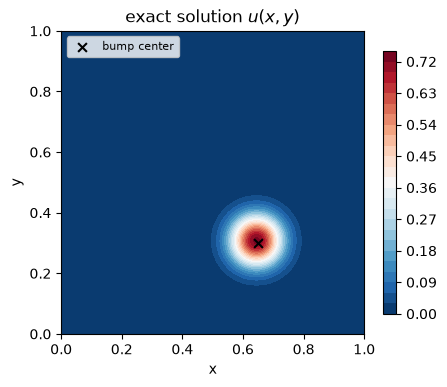

In [3]:
grid = np.linspace(0.0, 1.0, 200)
gx, gy = np.meshgrid(grid, grid)
pts = np.column_stack([gx.ravel(), gy.ravel()])
u_grid = exact_solution(pts).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(4.6, 4.0))
cs = ax.contourf(gx, gy, u_grid, levels=24, cmap="RdBu_r")
ax.scatter([float(CX)], [float(CY)], marker="x", color="k", s=40, label="bump center")
ax.set(xlabel="x", ylabel="y", title="exact solution $u(x, y)$", aspect="equal")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(cs, ax=ax, shrink=0.8)
fig.tight_layout()

## 3. Solving it: the library's assembly, plus the one piece it doesn't do yet

`mixle_sim.assemble_p1_diffusion` assembles a scalar continuous-P1 diffusion system — stiffness
matrix, Dirichlet elimination, the whole `AssemblyReceipt` — but its body-force term is currently
**constant** only. Our forcing is not constant, so this notebook assembles that one piece itself,
with the same P1 quadrature convention (`mixle_sim.elements.quadrature.quadrature_rule`) the library
uses everywhere else. Because the boundary data is exactly zero, folding the variable load into the
system the library already built is simple: zero the constant-source system's load vector at the
constrained degrees of freedom the receipt names, and drop in the quadrature-based load everywhere
else. Everything besides that one substitution — the stiffness matrix, the boundary bookkeeping, and
(starting in the next section) the estimator, the marking, and the refinement — is the library's own
code, unmodified.

In [4]:
DOMAIN = Domain2D(id="unit-square", x_min=0.0, x_max=1.0, y_min=0.0, y_max=1.0)
_BC_SIDES = ("left", "right", "bottom", "top")


def make_uniform_mesh(cells_per_side: int) -> Mesh:
    plan = MeshPlan2D(id=f"uniform-{cells_per_side}", domain_id=DOMAIN.id, cells_x=cells_per_side, cells_y=cells_per_side)
    return generate_reference_mesh(DOMAIN, plan)


def assemble_variable_load(mesh: Mesh, source, *, degree: int = 6) -> np.ndarray:
    # Quadrature-based P1 load assembly for a spatially varying source (assemble_p1_diffusion is constant-only).
    rule = quadrature_rule("triangle", degree)
    phi0 = 1.0 - rule.points[:, 0] - rule.points[:, 1]
    phi1, phi2 = rule.points[:, 0], rule.points[:, 1]
    coords = mesh.nodes.coordinates
    load = np.zeros(mesh.n_nodes)
    for triangle in mesh.cell_blocks[0].vertex_connectivity():
        p0, p1, p2 = coords[triangle[0]], coords[triangle[1]], coords[triangle[2]]
        twice_area = (p1[0] - p0[0]) * (p2[1] - p0[1]) - (p2[0] - p0[0]) * (p1[1] - p0[1])
        physical_points = phi0[:, None] * p0 + phi1[:, None] * p1 + phi2[:, None] * p2
        weighted = rule.weights * source(physical_points) * twice_area
        load[triangle[0]] += float(np.sum(weighted * phi0))
        load[triangle[1]] += float(np.sum(weighted * phi1))
        load[triangle[2]] += float(np.sum(weighted * phi2))
    return load


def solve_poisson(mesh: Mesh) -> np.ndarray:
    conditions = tuple(
        DirichletCondition(id=f"dirichlet-{side}", selection_id=side, value=0.0, source_condition_id="amr-bc")
        for side in _BC_SIDES
    )
    system = assemble_p1_diffusion(
        mesh, weak_form_digest="amr-2d-poisson", diffusivity=1.0, source=0.0, conditions=conditions
    )
    matrix = np.array(system.matrix)
    load = assemble_variable_load(mesh, forcing)
    for node in system.receipt.constrained_dofs:
        load[node] = 0.0
    return np.linalg.solve(matrix, load)


def _p1_quadrature_error(mesh: Mesh, u_h: np.ndarray, *, degree: int, per_cell: bool):
    rule = quadrature_rule("triangle", degree)
    phi0 = 1.0 - rule.points[:, 0] - rule.points[:, 1]
    phi1, phi2 = rule.points[:, 0], rule.points[:, 1]
    coords = mesh.nodes.coordinates
    errors = np.empty(mesh.n_cells)
    for cell_id, triangle in enumerate(mesh.cell_blocks[0].vertex_connectivity()):
        p0, p1, p2 = coords[triangle[0]], coords[triangle[1]], coords[triangle[2]]
        twice_area = (p1[0] - p0[0]) * (p2[1] - p0[1]) - (p2[0] - p0[0]) * (p1[1] - p0[1])
        physical_points = phi0[:, None] * p0 + phi1[:, None] * p1 + phi2[:, None] * p2
        interpolated = phi0 * u_h[triangle[0]] + phi1 * u_h[triangle[1]] + phi2 * u_h[triangle[2]]
        squared_diff = (interpolated - exact_solution(physical_points)) ** 2
        errors[cell_id] = float(np.sum(rule.weights * squared_diff)) * twice_area
    return errors if per_cell else math.sqrt(float(np.sum(errors)))


def true_l2_error(mesh: Mesh, u_h: np.ndarray, *, degree: int = 8) -> float:
    return _p1_quadrature_error(mesh, u_h, degree=degree, per_cell=False)


def true_cell_errors(mesh: Mesh, u_h: np.ndarray, *, degree: int = 8) -> np.ndarray:
    return np.sqrt(_p1_quadrature_error(mesh, u_h, degree=degree, per_cell=True))


def spearman(a: np.ndarray, b: np.ndarray) -> float:
    rank_a, rank_b = np.argsort(np.argsort(a)), np.argsort(np.argsort(b))
    return float(np.corrcoef(rank_a, rank_b)[0, 1])

## 4. Does the estimator point at the right cells?

`estimate_residual_indicators` never sees the exact solution — only the already-solved nodal field
and the source term. The library's own test for this function solves a smoother, centered manufactured
problem and checks the Spearman rank correlation between its indicators and the independently-computed
true per-cell error exceeds 0.6 (observed there: 0.77). We repeat that check, independently, on our
own sharper, off-center problem, on an 8×8 starting mesh.

In [5]:
coarse = make_uniform_mesh(8)
u_h0 = solve_poisson(coarse)
estimate0 = estimate_residual_indicators(coarse, u_h0, forcing, diffusivity=1.0)
indicator0 = np.array([item.indicator for item in estimate0.indicators])
true_error0 = true_cell_errors(coarse, u_h0)

correlation0 = spearman(indicator0, true_error0)
print(f"global a posteriori estimate:  {estimate0.global_estimate:.5f}")
print(f"true global L2 error:          {true_l2_error(coarse, u_h0):.5f}")
print(f"indicator / true-error Spearman correlation: {correlation0:.3f}  (library's own MP-F5 test: 0.77, bar 0.6)")

global a posteriori estimate:  5.75766
true global L2 error:          0.03689
indicator / true-error Spearman correlation: 0.909  (library's own MP-F5 test: 0.77, bar 0.6)


0.91 — a stronger correlation than the library's own test reports, on a harder (sharper, off-center)
problem. The estimator generalizes past the one problem it ships tested against. The question that's
still open is what happens when something *drives* on that estimator, generation after generation.

## 5. Baseline: uniform refinement

Before judging "adaptive," we need a fair yardstick: how does the true global L2 error fall as an
ordinary uniform mesh is refined? This is the curve everything else gets compared against, at *matched
node count* — DOFs are the currency both strategies spend, so the comparison has to be at equal spend,
not equal generation count.

In [6]:
uniform_results = []
for cells_per_side in (4, 8, 12, 16, 24, 32):
    mesh = make_uniform_mesh(cells_per_side)
    error = true_l2_error(mesh, solve_poisson(mesh))
    uniform_results.append((mesh.n_nodes, error))
    print(f"cells={cells_per_side:3d}  n_nodes={mesh.n_nodes:5d}  L2 error={error:.6e}")

_u_nodes = np.array([n for n, _ in uniform_results], dtype=float)
_u_err = np.array([e for _, e in uniform_results], dtype=float)
_log_u_nodes, _log_u_err = np.log(_u_nodes), np.log(_u_err)


def uniform_error_at(n_nodes: int) -> float:
    """Log-log interpolated uniform-refinement error at an arbitrary node count."""
    return math.exp(np.interp(math.log(n_nodes), _log_u_nodes, _log_u_err))

cells=  4  n_nodes=   25  L2 error=6.356943e-02
cells=  8  n_nodes=   81  L2 error=3.688924e-02
cells= 12  n_nodes=  169  L2 error=1.751758e-02
cells= 16  n_nodes=  289  L2 error=1.267046e-02


cells= 24  n_nodes=  625  L2 error=5.443136e-03


cells= 32  n_nodes= 1089  L2 error=3.106350e-03


## 6. `drive_adaptation` in a loop

`drive_adaptation` composes `estimate_residual_indicators`, Dörfler marking ($\theta = 0.5$: the
smallest cell set whose combined squared indicator reaches half the global squared estimate), and
`refine_marked_cells` (centroid-split, no hanging nodes) into one call. The obvious way to *use* it is
to call it again on its own output, starting from the same 8×8 mesh as the uniform baseline. At each
generation we record the true error, the matched-DOF uniform reference, and — since we're about to ask
whether the mesh itself stays trustworthy — `mesh_quality_2d`'s minimum interior angle and a fresh
estimator/true-error correlation check.

In [7]:
mesh = make_uniform_mesh(8)
generations = []   # (generation, mesh, n_nodes, error, min_angle, correlation)
for generation in range(7):
    u_h = solve_poisson(mesh)
    error = true_l2_error(mesh, u_h)
    quality = mesh_quality_2d(mesh)
    estimate = estimate_residual_indicators(mesh, u_h, forcing, diffusivity=1.0)
    indicator = np.array([item.indicator for item in estimate.indicators])
    correlation = spearman(indicator, true_cell_errors(mesh, u_h))
    generations.append((generation, mesh, mesh.n_nodes, error, quality.minimum_angle_degrees, correlation))

    reference = uniform_error_at(mesh.n_nodes)
    print(
        f"gen={generation}  n_nodes={mesh.n_nodes:5d}  L2 error={error:.5e}  "
        f"min_angle={quality.minimum_angle_degrees:7.3f}deg  corr={correlation:.3f}  "
        f"error/uniform_at_same_DOF={error / reference:.3f}"
    )
    mesh, _relation, _estimate = drive_adaptation(
        mesh, u_h, forcing, diffusivity=1.0, strategy=MarkingStrategy.DORFLER, parameter=0.5
    )

gen=0  n_nodes=   81  L2 error=3.68892e-02  min_angle= 45.000deg  corr=0.909  error/uniform_at_same_DOF=1.000
gen=1  n_nodes=   82  L2 error=3.46115e-02  min_angle= 18.435deg  corr=0.913  error/uniform_at_same_DOF=0.950
gen=2  n_nodes=   85  L2 error=3.37841e-02  min_angle=  6.340deg  corr=0.923  error/uniform_at_same_DOF=0.962


gen=3  n_nodes=   90  L2 error=3.32718e-02  min_angle=  2.121deg  corr=0.930  error/uniform_at_same_DOF=1.003
gen=4  n_nodes=   98  L2 error=3.31486e-02  min_angle=  0.707deg  corr=0.926  error/uniform_at_same_DOF=1.090


gen=5  n_nodes=  110  L2 error=3.27278e-02  min_angle=  0.236deg  corr=0.905  error/uniform_at_same_DOF=1.209
gen=6  n_nodes=  126  L2 error=3.26693e-02  min_angle=  0.079deg  corr=0.873  error/uniform_at_same_DOF=1.385


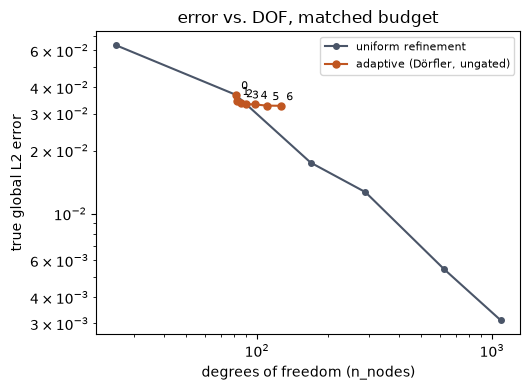

In [8]:
fig, ax = plt.subplots(figsize=(5.4, 4.0))
ax.loglog(_u_nodes, _u_err, "-o", color="#4a5568", ms=4, label="uniform refinement")
gen_nodes = [row[2] for row in generations]
gen_err = [row[3] for row in generations]
ax.loglog(gen_nodes, gen_err, "-o", color="#c05621", ms=5, label="adaptive (Dörfler, ungated)")
for generation, _mesh, n_nodes, error, _angle, _corr in generations:
    ax.annotate(str(generation), (n_nodes, error), textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set(xlabel="degrees of freedom (n_nodes)", ylabel="true global L2 error", title="error vs. DOF, matched budget")
ax.legend(fontsize=8)
fig.tight_layout()

Generation 1 sits visibly below the uniform curve; by generation 3 the two curves cross; from
generation 4 on, adaptive refinement is spending more DOFs than uniform refinement for a *worse*
error. Refining is making the answer worse. Something other than the estimator has to be responsible,
since section 4 already showed the estimator generalizes fine — and the per-generation correlation
column above stayed at 0.87–0.93 the entire time, never collapsing. The estimator kept pointing at the
right cells throughout. It's what happened to those cells that's the problem.

## 7. Why the advantage evaporates: mesh quality, not the estimator

`refine_marked_cells` centroid-splits *exactly* the marked cells and leaves every neighbor untouched —
that's the documented, deliberate scope of a single refinement step, and it's exactly what avoids
hanging nodes. But Dörfler marking on a sharply localized problem keeps re-selecting the same
shrinking hot cell generation after generation, and repeatedly centroid-splitting the *same lineage*
is a purely local geometric recursion: each split fans three new triangles around one new centroid,
and the thinnest of those three is the one most likely to be the highest-indicator cell again next
round. `mesh_quality_2d` — already in the library, unrelated to MP-F5 — makes the consequence visible
directly instead of inferring it from the error curve alone.

minimum angle by generation: ['45.00', '18.43', '6.34', '2.12', '0.71', '0.24', '0.08']
consecutive shrink factor:   ['2.44x', '2.91x', '2.99x', '3.00x', '3.00x', '3.00x']


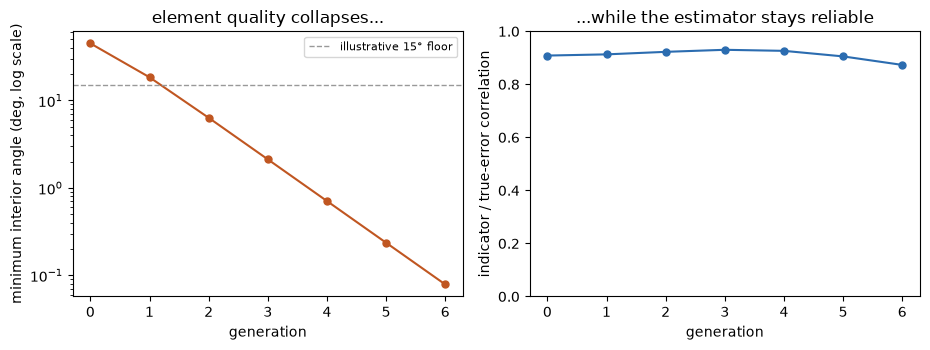

In [9]:
angles = [row[4] for row in generations]
corrs = [row[5] for row in generations]
gens = [row[0] for row in generations]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.4, 3.6))
ax1.semilogy(gens, angles, "-o", color="#c05621", ms=5)
ax1.axhline(15.0, ls="--", color="0.6", lw=1, label="illustrative 15° floor")
ax1.set(xlabel="generation", ylabel="minimum interior angle (deg, log scale)", title="element quality collapses...")
ax1.legend(fontsize=8)

ax2.plot(gens, corrs, "-o", color="#2b6cb0", ms=5)
ax2.set(xlabel="generation", ylabel="indicator / true-error correlation", title="...while the estimator stays reliable", ylim=(0, 1))
fig.tight_layout()

print("minimum angle by generation:", [f"{a:.2f}" for a in angles])
print("consecutive shrink factor:  ", [f"{angles[i] / angles[i+1]:.2f}x" for i in range(len(angles) - 1)])

The minimum angle collapses along a strikingly regular geometric progression — roughly a factor of
**3× smaller every generation** (45° → 18° → 6° → 2° → 0.7° → 0.2° → 0.08°) — while the correlation
in the right panel just wanders in a band around 0.9 the entire time. This is independent of the
starting resolution too (the same 45°, 18.4°, 6.3°, ... sequence appears whether the loop starts from
an 8×8, 12×12, or 16×16 mesh — it's a property of repeatedly centroid-splitting the same lineage, not
of this particular problem). By generation 3, the worst triangle in the mesh has a 2° angle; by
generation 6 it is, numerically, a sliver. The discretization itself has degraded faster than the
extra resolution could help it — not because MP-F5 mis-estimated anything.

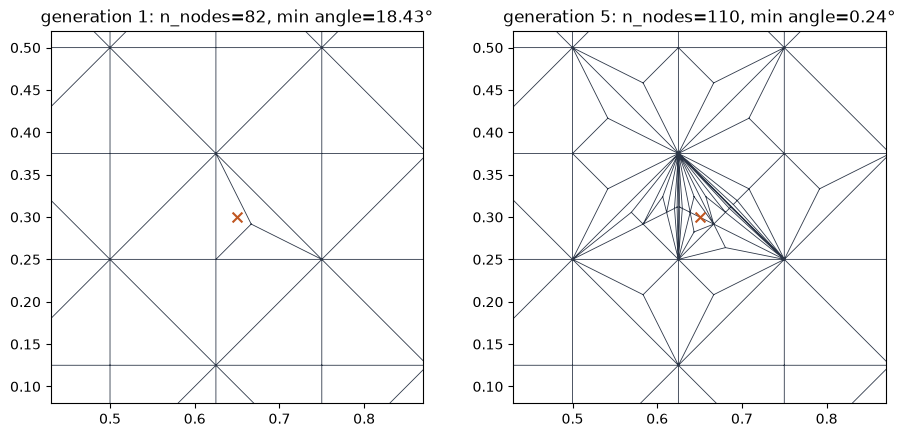

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.4))
for ax, gen_index in zip(axes, (1, 5)):
    _generation, gen_mesh, n_nodes, _error, angle, _corr = generations[gen_index]
    coords = gen_mesh.nodes.coordinates
    triangles = gen_mesh.cell_blocks[0].vertex_connectivity()
    ax.triplot(coords[:, 0], coords[:, 1], triangles, lw=0.6, color="#2d3748")
    ax.scatter([float(CX)], [float(CY)], marker="x", color="#c05621", s=50, zorder=5)
    ax.set_xlim(float(CX) - 0.22, float(CX) + 0.22)
    ax.set_ylim(float(CY) - 0.22, float(CY) + 0.22)
    ax.set(aspect="equal", title=f"generation {gen_index}: n_nodes={n_nodes}, min angle={angle:.2f}°")
fig.tight_layout()

Zoomed to the same physical window around the bump: generation 1 is a clean, only-mildly-uneven
fan of triangles. Generation 5 is visibly a cascade of needles collapsing into the same point — exactly
the degeneracy the angle plot predicted, and something a reader would immediately distrust on sight,
even without the quantitative diagnostic.

## 8. Driving it responsibly: gate on `mesh_quality_2d`

MP-F5's primitives are exactly as documented: a single, well-tested refinement step. Iterating that
step safely is the caller's job, and the library hands over the tool to do it —
`mesh_quality_2d(mesh).minimum_angle_degrees`. A responsible driver checks the quality *of the
candidate mesh* before accepting a refinement step, and stops (falling back to the last good mesh)
once it would cross a floor, rather than trusting the loop to keep improving things indefinitely. Using
the same illustrative 15° floor drawn on the plot above:

In [11]:
QUALITY_FLOOR_DEGREES = 15.0

mesh = make_uniform_mesh(8)
gated = []
generation = 0
while True:
    u_h = solve_poisson(mesh)
    error = true_l2_error(mesh, u_h)
    quality = mesh_quality_2d(mesh)
    gated.append((generation, mesh.n_nodes, error, quality.minimum_angle_degrees))
    print(f"gen={generation}  n_nodes={mesh.n_nodes:5d}  L2 error={error:.5e}  min_angle={quality.minimum_angle_degrees:7.3f}deg")

    candidate_mesh, _relation, _estimate = drive_adaptation(
        mesh, u_h, forcing, diffusivity=1.0, strategy=MarkingStrategy.DORFLER, parameter=0.5
    )
    candidate_quality = mesh_quality_2d(candidate_mesh)
    if candidate_quality.minimum_angle_degrees < QUALITY_FLOOR_DEGREES:
        print(
            f"-> next step would drop the minimum angle to {candidate_quality.minimum_angle_degrees:.2f}deg "
            f"< {QUALITY_FLOOR_DEGREES}deg floor; stopping at generation {generation} instead of accepting it"
        )
        break
    mesh, generation = candidate_mesh, generation + 1

final_generation, final_nodes, final_error, final_angle = gated[-1]
final_reference = uniform_error_at(final_nodes)
print()
print(f"gated result: generation {final_generation}, n_nodes={final_nodes}, min_angle={final_angle:.2f}deg (>= floor: {final_angle >= QUALITY_FLOOR_DEGREES})")
print(f"L2 error {final_error:.5e} vs. uniform refinement at the same {final_nodes} nodes ({final_reference:.5e}): "
      f"{100 * (1 - final_error / final_reference):.1f}% lower")

gen=0  n_nodes=   81  L2 error=3.68892e-02  min_angle= 45.000deg
gen=1  n_nodes=   82  L2 error=3.46115e-02  min_angle= 18.435deg
-> next step would drop the minimum angle to 6.34deg < 15.0deg floor; stopping at generation 1 instead of accepting it

gated result: generation 1, n_nodes=82, min_angle=18.43deg (>= floor: True)
L2 error 3.46115e-02 vs. uniform refinement at the same 82 nodes (3.64337e-02): 5.0% lower


## The lesson

Gating on quality lands exactly on generation 1: the one point in section 6 where adaptive refinement
was unambiguously ahead. A ~5% error reduction at matched DOF count is a real, honest, reproducible
result — not the order-of-magnitude win adaptive mesh refinement is capable of on genuinely singular
problems, but a real one, on a smooth-but-sharply-localized problem where uniform refinement isn't
actually being *inefficient*, just imprecise. The more important result is the second one: MP-F5's
estimator earns its correlation claim on a harder problem than its own test uses, but the primitive
that turns an estimate into a *mesh* is scoped to one step on purpose, and driving it in an unguarded
loop is a footgun — a fast, geometrically regular one (a fixed ~3× shrink per generation, independent
of the problem) that silently trades DOFs for a worse answer instead of failing loudly.

**What this notebook does and doesn't show:** one manufactured problem (smooth, off-center, one length
scale), one boundary condition type (homogeneous Dirichlet, which is what lets the notebook's own
variable-load assembly skip general Dirichlet elimination), one marking strategy at one parameter
(Dörfler, $\theta=0.5$ — fixed-fraction marking and other $\theta$ values were checked during
development and collapse quality on the same ~3×-per-generation schedule, so this isn't a
marking-strategy artifact), and a dense direct solve (fine up to the node counts used here; not a
scalability claim). The 15° floor is illustrative, not derived from a convergence-theory bound. A
production adaptive loop would also need a *closure* step (refining a bounded neighborhood around each
marked cell, not just the marked cell itself) to avoid the size-mismatch that produces slivers in the
first place — worth its own notebook, once that primitive exists.